# Titanic Dataset Exploratory Data Analysis (EDA)

AVIP 2026 Data Science Task 2

## Objective

This notebook performs a complete exploratory analysis of the Kaggle Titanic training dataset. It focuses on data quality, documented cleaning, interpretable feature engineering, descriptive analysis, and reproducible visualizations. No machine-learning model is used.

## Dataset Information

The dataset was downloaded from Kaggle: https://www.kaggle.com/competitions/titanic/data

`train.csv` contains passenger details such as class, sex, age, family relationships, fare, cabin, embarkation port, and the observed survival outcome.

## Import Libraries

The analysis uses only the requested beginner-friendly data-science libraries.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

sns.set_theme(style="whitegrid", palette="deep")
pd.set_option("display.max_columns", None)

PROJECT_ROOT = Path.cwd()
DATA_PATH = PROJECT_ROOT / "data/train.csv"
if not DATA_PATH.exists():
    PROJECT_ROOT = PROJECT_ROOT.parent
    DATA_PATH = PROJECT_ROOT / "data/train.csv"
CHARTS_PATH = PROJECT_ROOT / "charts"
CHARTS_PATH.mkdir(exist_ok=True)


## Load Dataset

In [2]:
df = pd.read_csv(DATA_PATH)

print(f"Loaded dataset from: {DATA_PATH}")
print(f"Rows: {df.shape[0]:,} | Columns: {df.shape[1]}")
display(df.head())


Loaded dataset from: C:\Users\prana\Desktop\DS_2_Titanic_EDA_byte\data\train.csv
Rows: 891 | Columns: 12


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


## Initial Data Inspection

The following checks establish the dataset dimensions, fields, data types, and numeric summary before any changes are made.

In [3]:
print("Shape:", df.shape)
print("\nColumn names:")
print(df.columns.tolist())
print("\nData types:")
display(df.dtypes.to_frame("dtype"))
print("\nBasic statistical summary:")
display(df.describe(include="all").T)

print("\nUseful unique-value counts:")
display(df[["Survived", "Pclass", "Sex", "Embarked"]].nunique().to_frame("unique_values"))

print("\nData-quality observations:")
print(f"- The dataset contains {df.shape[0]:,} rows and {df.shape[1]} columns.")
print(f"- Age has {df['Age'].isna().sum()} missing values and Cabin has {df['Cabin'].isna().sum()} missing values.")
print(f"- There are {df.duplicated().sum()} duplicate rows before cleaning.")


Shape: (891, 12)

Column names:
['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp', 'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked']

Data types:


,dtype
PassengerId,int64
Survived,int64
Pclass,int64
Name,object
Sex,object
Age,float64
SibSp,int64
Parch,int64
Ticket,object
Fare,float64



Basic statistical summary:


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
PassengerId,891.0,NaN,NaN,NaN,446.0,257.353842,1.0,223.5,446.0,668.5,891.0
Survived,891.0,NaN,NaN,NaN,0.383838,0.486592,0.0,0.0,0.0,1.0,1.0
Pclass,891.0,NaN,NaN,NaN,2.308642,0.836071,1.0,2.0,3.0,3.0,3.0
Name,891,891,"Braund, Mr. Owen Harris",1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Sex,891,2,male,577,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Age,714.0,NaN,NaN,NaN,29.699118,14.526497,0.42,20.125,28.0,38.0,80.0
SibSp,891.0,NaN,NaN,NaN,0.523008,1.102743,0.0,0.0,0.0,1.0,8.0
Parch,891.0,NaN,NaN,NaN,0.381594,0.806057,0.0,0.0,0.0,0.0,6.0
Ticket,891,681,347082,7,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Fare,891.0,NaN,NaN,NaN,32.204208,49.693429,0.0,7.9104,14.4542,31.0,512.3292



Useful unique-value counts:


,unique_values
Survived,2
Pclass,3
Sex,2
Embarked,3



Data-quality observations:
- The dataset contains 891 rows and 12 columns.
- Age has 177 missing values and Cabin has 687 missing values.
- There are 0 duplicate rows before cleaning.


## Data Quality Check

Duplicate rows and missing values are measured before cleaning so that the effect of each decision can be shown later.

In [4]:
duplicate_count = df.duplicated().sum()
missing_before = df.isna().sum().sort_values(ascending=False)

print(f"Duplicate rows: {duplicate_count}")
print("Missing values before cleaning:")
display(missing_before.to_frame("missing_count"))


Duplicate rows: 0
Missing values before cleaning:


,missing_count
Cabin,687
Age,177
Embarked,2
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
SibSp,0
Parch,0


## Data Cleaning

- Duplicate rows are removed only if present.
- Missing `Age` values are filled with the median age because the median is less affected by extreme fares or ages than the mean.
- Missing `Embarked` values are filled with the mode because this is a categorical field and only two values are missing.
- `Cabin` is retained as recorded. Its many missing values make reliable cabin-level imputation inappropriate, so the analysis uses a `CabinKnown` indicator rather than inventing cabin identifiers.

The raw data is copied before cleaning to preserve a clear before/after comparison.

In [5]:
clean_df = df.copy()
clean_df = clean_df.drop_duplicates().copy()

age_median = clean_df["Age"].median()
embarked_mode = clean_df["Embarked"].mode().iloc[0]
clean_df["Age"] = clean_df["Age"].fillna(age_median)
clean_df["Embarked"] = clean_df["Embarked"].fillna(embarked_mode)

missing_after = clean_df.isna().sum().sort_values(ascending=False)
comparison = pd.DataFrame({"before": missing_before, "after": missing_after}).fillna(0).astype(int)
print(f"Median used for Age: {age_median:.2f}")
print(f"Mode used for Embarked: {embarked_mode}")
print("Missing values before and after cleaning:")
display(comparison)
print("Cabin remains available for completeness analysis; missing Cabin values are not fabricated.")


Median used for Age: 28.00
Mode used for Embarked: S
Missing values before and after cleaning:


,before,after
Age,177,0
Cabin,687,687
Embarked,2,0
Fare,0,0
Name,0,0
Parch,0,0
PassengerId,0,0
Pclass,0,0
Sex,0,0
SibSp,0,0


Cabin remains available for completeness analysis; missing Cabin values are not fabricated.


## Feature Engineering

These features summarize relationships that are more useful for EDA than inspecting raw columns alone:

- `FamilySize` counts the passenger plus siblings/spouses and parents/children traveling with them.
- `IsAlone` separates solo travelers from passengers traveling with family.
- `AgeGroup` makes age patterns easier to compare across life-stage bands.
- `CabinKnown` records whether a cabin was listed without trying to infer missing cabin numbers.

In [6]:
clean_df["FamilySize"] = clean_df["SibSp"] + clean_df["Parch"] + 1
clean_df["IsAlone"] = (clean_df["FamilySize"] == 1).astype(int)
clean_df["AgeGroup"] = pd.cut(
    clean_df["Age"],
    bins=[0, 12, 18, 35, 60, np.inf],
    labels=["Child", "Teenager", "Young Adult", "Adult", "Senior"],
    include_lowest=True,
)
clean_df["CabinKnown"] = clean_df["Cabin"].notna().astype(int)

CLEANED_DATA_PATH = PROJECT_ROOT / "data/cleaned_train.csv"
clean_df.to_csv(CLEANED_DATA_PATH, index=False)
print(f"Saved cleaned dataset with engineered features to: {CLEANED_DATA_PATH}")
display(clean_df[["FamilySize", "IsAlone", "AgeGroup", "CabinKnown"]].head())


Saved cleaned dataset with engineered features to: C:\Users\prana\Desktop\DS_2_Titanic_EDA_byte\data\cleaned_train.csv


,FamilySize,IsAlone,AgeGroup,CabinKnown
0,2,0,Young Adult,0
1,2,0,Adult,1
2,1,1,Young Adult,0
3,2,0,Young Adult,1
4,1,1,Young Adult,0


## Exploratory Data Analysis

The tables below quantify survival patterns for the requested passenger characteristics.

In [7]:
overall_survival_rate = clean_df["Survived"].mean()
print(f"Overall survival rate: {overall_survival_rate:.1%}")

analysis_tables = {
    "Survival by gender": clean_df.groupby("Sex", observed=True)["Survived"].agg(["count", "mean"]).rename(columns={"mean": "survival_rate"}),
    "Survival by passenger class": clean_df.groupby("Pclass", observed=True)["Survived"].agg(["count", "mean"]).rename(columns={"mean": "survival_rate"}),
    "Survival by embarkation port": clean_df.groupby("Embarked", observed=True)["Survived"].agg(["count", "mean"]).rename(columns={"mean": "survival_rate"}),
    "Survival by age group": clean_df.groupby("AgeGroup", observed=True)["Survived"].agg(["count", "mean"]).rename(columns={"mean": "survival_rate"}),
    "Survival by family size": clean_df.groupby("FamilySize", observed=True)["Survived"].agg(["count", "mean"]).rename(columns={"mean": "survival_rate"}),
}
for title, table in analysis_tables.items():
    print(f"\n{title}")
    display(table)

print("\nNumeric feature summary:")
display(clean_df[["Age", "Fare", "FamilySize"]].describe().T)


Overall survival rate: 38.4%

Survival by gender


,count,survival_rate
Sex,,
female,314,0.742038
male,577,0.188908



Survival by passenger class


,count,survival_rate
Pclass,,
1,216,0.629630
2,184,0.472826
3,491,0.242363



Survival by embarkation port


...

,count,survival_rate
AgeGroup,,
Child,69,0.579710
Teenager,70,0.428571
Young Adult,535,0.353271
Adult,195,0.400000
Senior,22,0.227273



Survival by family size


,count,survival_rate
FamilySize,,
1,537,0.303538
2,161,0.552795
3,102,0.578431
4,29,0.724138
5,15,0.200000
6,22,0.136364
7,12,0.333333
8,6,0.000000
11,7,0.000000



Numeric feature summary:


,count,mean,std,min,25%,50%,75%,max
Age,891.0,29.361582,13.019697,0.42,22.0000,28.0000,35.0,80.0000
Fare,891.0,32.204208,49.693429,0.00,7.9104,14.4542,31.0,512.3292
FamilySize,891.0,1.904602,1.613459,1.00,1.0000,1.0000,2.0,11.0000


## Required Visualizations

The next three charts are saved with the exact filenames required by the task.

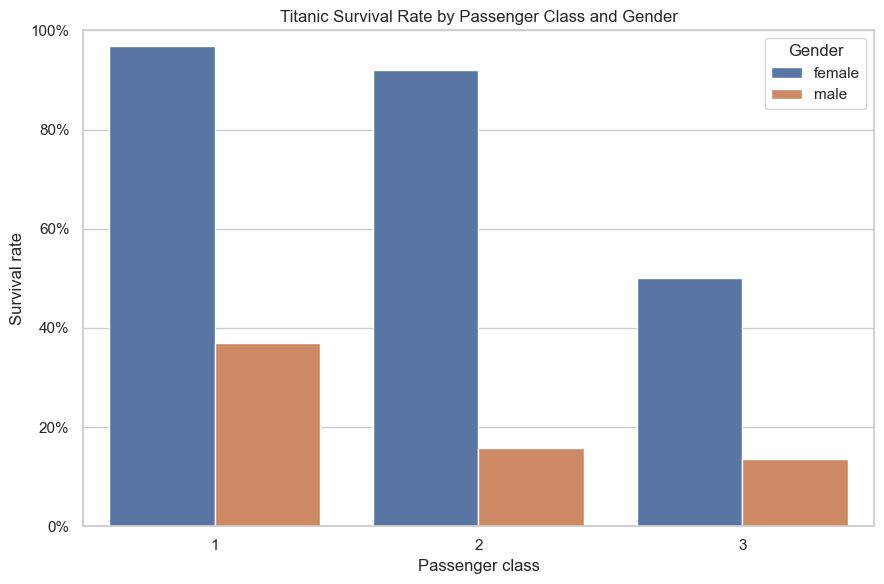

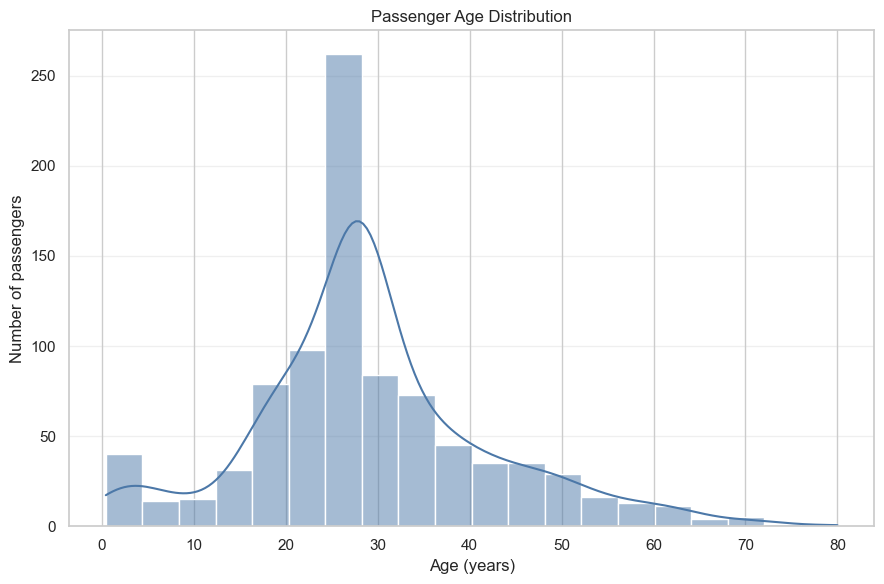

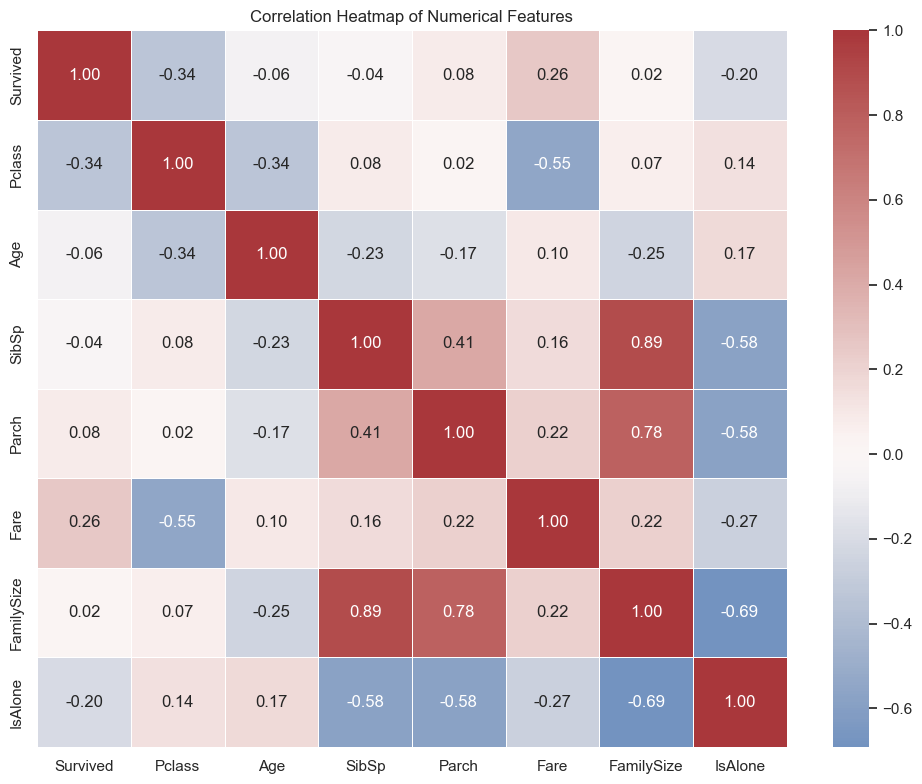

In [8]:
survival_by_class_gender = clean_df.groupby(["Pclass", "Sex"], observed=True)["Survived"].mean().reset_index()
fig, ax = plt.subplots(figsize=(9, 6))
sns.barplot(data=survival_by_class_gender, x="Pclass", y="Survived", hue="Sex", ax=ax)
ax.set_title("Titanic Survival Rate by Passenger Class and Gender")
ax.set_xlabel("Passenger class")
ax.set_ylabel("Survival rate")
ax.set_ylim(0, 1)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda value, _: f"{value:.0%}"))
ax.legend(title="Gender")
fig.tight_layout()
fig.savefig(CHARTS_PATH / "survival_by_class_gender.png", dpi=150, bbox_inches="tight")
plt.show()
plt.close(fig)

fig, ax = plt.subplots(figsize=(9, 6))
sns.histplot(data=clean_df, x="Age", bins=20, kde=True, color="#4C78A8", ax=ax)
ax.set_title("Passenger Age Distribution")
ax.set_xlabel("Age (years)")
ax.set_ylabel("Number of passengers")
ax.grid(axis="y", alpha=0.3)
fig.tight_layout()
fig.savefig(CHARTS_PATH / "age_distribution.png", dpi=150, bbox_inches="tight")
plt.show()
plt.close(fig)

correlation_columns = ["Survived", "Pclass", "Age", "SibSp", "Parch", "Fare", "FamilySize", "IsAlone"]
correlation_matrix = clean_df[correlation_columns].corr()
fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, fmt=".2f", cmap="vlag", center=0, linewidths=0.5, ax=ax)
ax.set_title("Correlation Heatmap of Numerical Features")
fig.tight_layout()
fig.savefig(CHARTS_PATH / "correlation_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()
plt.close(fig)


## Additional Visualizations

These focused charts add context without duplicating the required visuals.

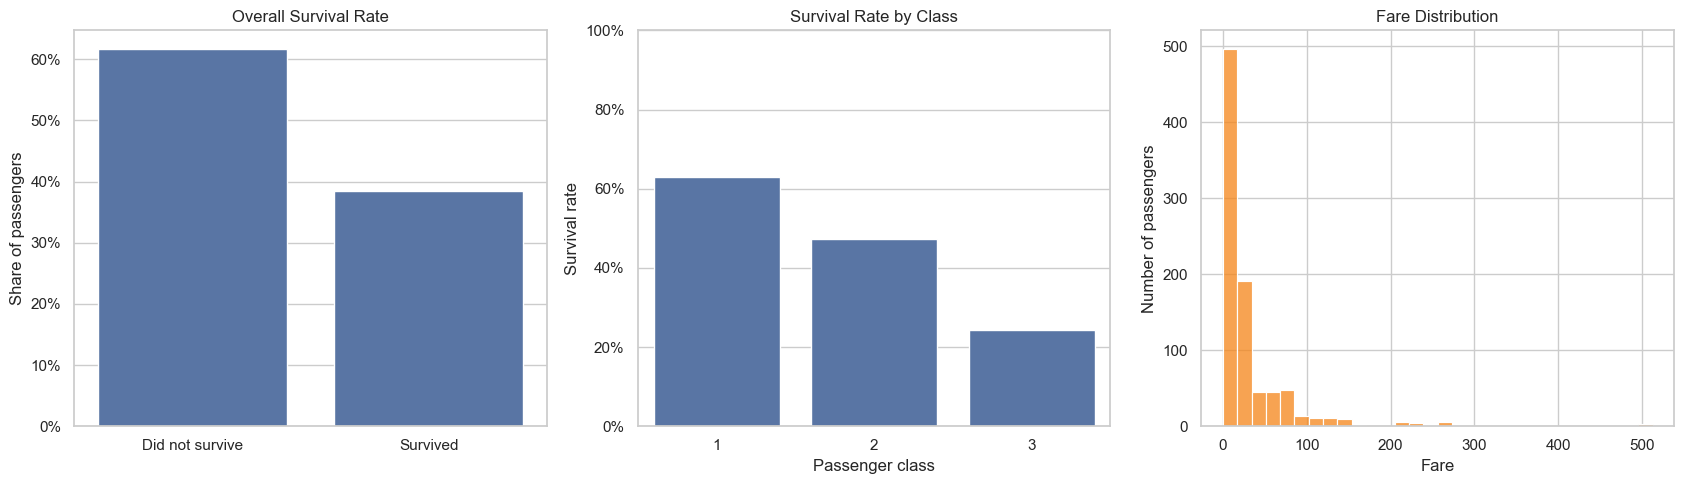

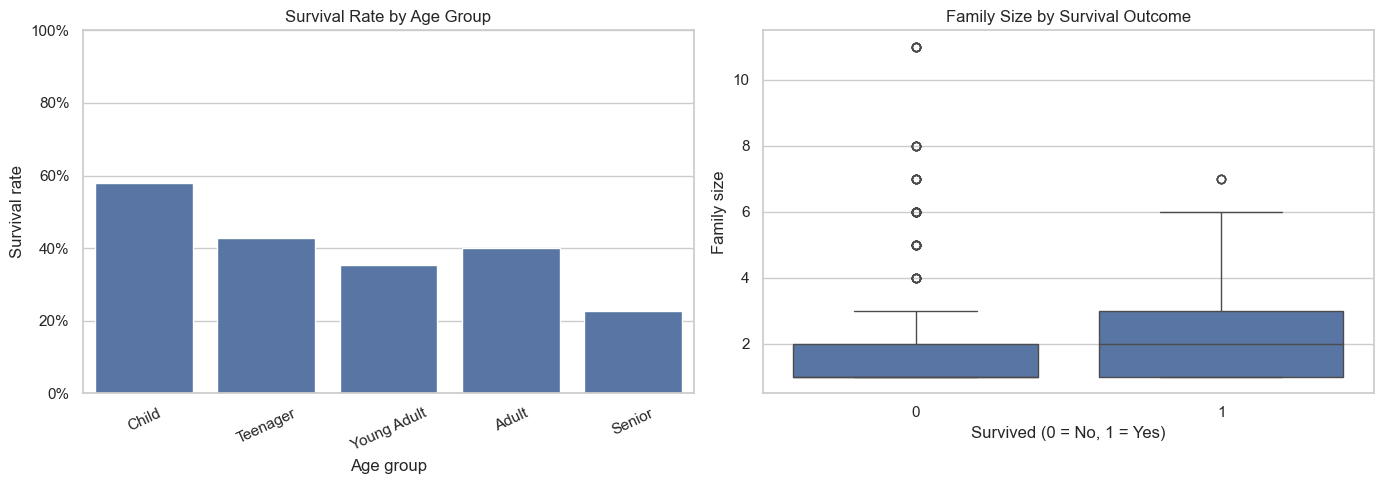

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(17, 5))
sns.barplot(x=["Did not survive", "Survived"], y=clean_df["Survived"].value_counts(normalize=True).sort_index().values, ax=axes[0])
axes[0].set_title("Overall Survival Rate")
axes[0].set_ylabel("Share of passengers")
axes[0].yaxis.set_major_formatter(plt.FuncFormatter(lambda value, _: f"{value:.0%}"))

class_rates = clean_df.groupby("Pclass", observed=True)["Survived"].mean()
sns.barplot(x=class_rates.index, y=class_rates.values, ax=axes[1])
axes[1].set_title("Survival Rate by Class")
axes[1].set_xlabel("Passenger class")
axes[1].set_ylabel("Survival rate")
axes[1].set_ylim(0, 1)
axes[1].yaxis.set_major_formatter(plt.FuncFormatter(lambda value, _: f"{value:.0%}"))

sns.histplot(data=clean_df, x="Fare", bins=30, color="#F58518", ax=axes[2])
axes[2].set_title("Fare Distribution")
axes[2].set_xlabel("Fare")
axes[2].set_ylabel("Number of passengers")
fig.tight_layout()
fig.savefig(CHARTS_PATH / "additional_distributions.png", dpi=150, bbox_inches="tight")
plt.show()
plt.close(fig)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
age_group_rates = clean_df.groupby("AgeGroup", observed=True)["Survived"].mean()
sns.barplot(x=age_group_rates.index, y=age_group_rates.values, ax=axes[0])
axes[0].set_title("Survival Rate by Age Group")
axes[0].set_xlabel("Age group")
axes[0].set_ylabel("Survival rate")
axes[0].tick_params(axis="x", rotation=25)
axes[0].set_ylim(0, 1)
axes[0].yaxis.set_major_formatter(plt.FuncFormatter(lambda value, _: f"{value:.0%}"))

sns.boxplot(data=clean_df, x="Survived", y="FamilySize", ax=axes[1])
axes[1].set_title("Family Size by Survival Outcome")
axes[1].set_xlabel("Survived (0 = No, 1 = Yes)")
axes[1].set_ylabel("Family size")
fig.tight_layout()
fig.savefig(CHARTS_PATH / "age_group_and_family_size.png", dpi=150, bbox_inches="tight")
plt.show()
plt.close(fig)


## Key Findings

The tables and charts show that survival is not evenly distributed across the passenger population. The class-and-gender chart is especially useful because it compares two important attributes at the same time, while the heatmap summarizes linear relationships among numeric variables.

## Actionable Observations

1. **Passenger class is strongly associated with observed survival.** The `Survival by passenger class` table and the class chart compare the survival rate for first-, second-, and third-class passengers. This supports prioritizing class when describing survival differences in this dataset; it does not establish causation.

2. **Gender differences are visible across passenger classes.** The required `survival_by_class_gender.png` chart shows the observed survival rate for females and males within each class. The comparison supports reporting gender and class together rather than relying on an overall gender average alone.

3. **Age and family context provide additional segmentation.** The age-distribution chart, age-group table, and family-size analysis show how the passenger population and survival rates vary across age bands and family sizes. These groups can make future descriptive reporting more precise, while the analysis avoids claiming that family size or age alone caused an outcome.

4. **Fare should be interpreted alongside class.** The correlation heatmap and fare distribution show that fare is a numeric measure related to the passenger experience and is not independent of class. Comparing fare and class together avoids presenting a simple fare relationship as an isolated effect.

## Conclusion

This EDA loaded and quality-checked the Kaggle Titanic data, documented transparent cleaning choices, created interpretable family and age features, and analyzed survival patterns with reproducible visualizations.

The analysis indicates that passenger class and gender are associated with different observed survival rates, while age and family-size groups provide useful additional context. Fare should be interpreted alongside class because these variables are related. These conclusions describe associations in this dataset; they do not prove causation and no machine-learning model is used.